### Imports 👽

In [27]:
import os, sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import math
import numpy as np

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from data_classes.enums import Scenario, SamplingMethod

### Prepare Data to Compare ⚙️

In [56]:
scenario = Scenario.SUM_SINES_10D

output_path = os.path.abspath(os.path.join('..', 'data', scenario.value, 'output', 'together3.csv'))
data = pd.read_csv(output_path)

In [61]:
str(SamplingMethod.SOBOL)

'SamplingMethod.SOBOL'

### Analysis 📊

In [ ]:
# CONFIGURATION
sampling_methods = [str(SamplingMethod.SOBOL)]

widths = [6,12,24]
depths = [4,8,16]
learning_rates = [0.01,0.001]
# lambdas = [1.0e-04,1.0e-05,1.0e-06,1e-07]
# learning_rates = [1.0e-04,1.0e-05,1.0e-06,1e-07]
learning_rates = [1.0e-04,1.0e-05,1.0e-06,1e-07]
lambdas = [0.01,0.001]
training_set_sizes = [2**i for i in range(5,14)]

data = data.loc[
    data['learning_rate'].isin(learning_rates) &
    data['reg_param'].isin(lambdas) &
    data['depth'].isin(depths) &
    data['NumSamples'].isin(training_set_sizes)  &
    data['SamplingMethod'].isin(sampling_methods)
]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (754764352.py, line 14)

In [59]:
data.head(500)

,Unnamed: 0,learning_rate,reg_param,batch_norm,depth,num_hidden_layers,activation,train_error,test_error,epoch,optim_time,SamplingMethod,NumSamples
0,0,0.0001,0.001,True,16,6,Sigmoid,2.203414,1.402293,1499,4.642694,SamplingMethod.SOBOL,4096
1,1,0.0001,0.001,True,16,6,Sigmoid,2.200068,1.402300,1500,4.645634,SamplingMethod.SOBOL,4096
2,2,0.0001,0.001,True,16,6,Sigmoid,2.206763,1.402911,1498,4.638915,SamplingMethod.SOBOL,4096
3,3,0.0001,0.001,True,16,6,Sigmoid,2.210116,1.403130,1497,4.635935,SamplingMethod.SOBOL,4096
4,4,0.0001,0.001,True,16,6,Sigmoid,2.213471,1.403857,1496,4.632955,SamplingMethod.SOBOL,4096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,0.0001,0.001,True,16,6,Sigmoid,3.872733,2.071288,1065,3.297174,SamplingMethod.SOBOL,4096
496,496,0.0001,0.010,True,16,6,Sigmoid,4.387730,2.071877,1440,4.834978,SamplingMethod.SOBOL,4096
497,497,0.0001,0.001,True,16,6,Sigmoid,3.877018,2.072420,1064,3.294245,SamplingMethod.SOBOL,4096
498,498,0.0001,0.010,True,16,6,Sigmoid,4.392265,2.073427,1439,4.831695,SamplingMethod.SOBOL,4096


In [ ]:
sns.boxplot(data=together_df, x="sampling_type", y="test_error")
sns.boxplot(data=together_df, x="sampling_type", y="test_error", showmeans=True,
            meanprops={"marker":"s","markerfacecolor":"white", "markeredgecolor":"blue"})

plt.title("Test Error Distribution by Sampling Type")
plt.ylabel("Test Error (L1 Loss)")
plt.xlabel("Sampling Type")
plt.show()

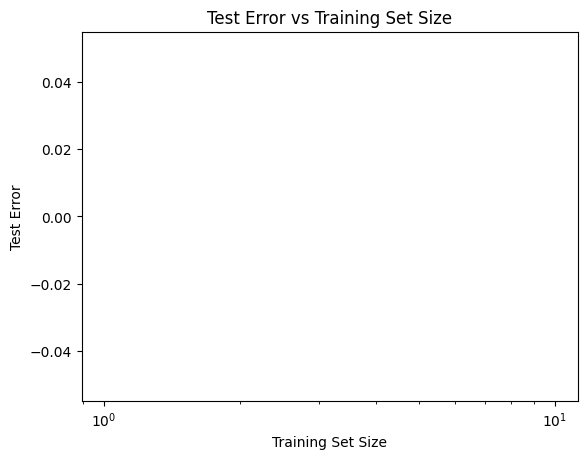

In [8]:
sns.lineplot(
    data=data,
    x="NumSamples",
    y="test_error",
    hue="SamplingMethod",
    marker="o"
)
x_vals = np.array(sorted(data['NumSamples'].unique()), dtype=float)
def diff_func(x):
    return np.sqrt(x)/np.log(x)**6
y_vals = diff_func(x_vals)
plt.plot(x_vals, 30*y_vals, label='y = sqrt(x) / log(x)^6', color='red', linestyle='--')
plt.title("Test Error vs Training Set Size")
plt.ylabel("Test Error")
plt.xlabel("Training Set Size")
plt.xscale("log")  # if sizes vary exponentially
plt.show()


In [ ]:
sns.scatterplot(
    data=together_df,
    x="train_error",
    y="test_error",
    hue="sampling_type",
    style="sampling_type",
    size="train_size"
)
plt.title("Train vs Test Error by Sampling Type")
plt.plot([0, 1], [0, 1], ls="--", c="gray")  # identity line
plt.xlabel("Train Error")
plt.ylabel("Test Error")
plt.show()


In [ ]:
for method in ["sobol", "mc"]:
    pivot = together_df[together_df["sampling_type"] == method].pivot_table(
        index="learning_rate",
        columns="reg_param",
        values="test_error",
        aggfunc="mean"
    )
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Mean Test Error Heatmap ({method.upper()})")
    plt.ylabel("Learning Rate")
    plt.xlabel("Reg Param")
    plt.show()


In [ ]:
together_df.loc[(together_df.depth == 4) & (together_df.sampling_type == 'sobol')]

In [ ]:
g = sns.FacetGrid(
    together_df, col="sampling_type", height=4, aspect=1.2
)
g.map_dataframe(sns.lineplot, x="depth", y="test_error", marker="o")
g.set_axis_labels("Network Depth", "Test Error")
g.set_titles(col_template="{col_name}")
plt.suptitle("Test Error vs Network Depth by Sampling Type", y=1.05)
plt.show()


In [ ]:
model = smf.ols('test_error ~ sampling_type + train_size + reg_param + learning_rate', data=together_df).fit()
print(model.summary())